# Earthquake Analysis (1990–2023)

**Objective:** Analyze global earthquake data from 1990 to 2023 to uncover patterns in magnitude, depth, location, and frequency over time. The analysis includes exploratory data analysis (EDA), trend visualization by year and month, identification of the strongest earthquakes by state, and a machine learning model to predict earthquake magnitude based on geographic and depth features.

**Dataset:** `Eartquakes-1990-2023.csv` — ~3.4 million records with columns: time, place, status, tsunami, significance, data_type, magnitudo, state, longitude, latitude, depth, date.

---

### Step 1 — Import Libraries
Load the core libraries needed for data manipulation (`pandas`), static visualization (`matplotlib`, `seaborn`), and interactive visualization (`plotly`).

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2 — Load the Dataset
Read the CSV file into a pandas DataFrame and preview the first 5 rows to confirm the data loaded correctly.

In [2]:
# Load the earthquake dataset
import os
os.getcwd()

df = pd.read_csv('Eartquakes-1990-2023.csv')
df.head()

,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00
1,631153491210,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00
2,631154083450,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00
3,631155512130,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00
4,631155824490,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00


### Step 3 — Inspect Data Structure
Display column names, data types, and the number of non-null values to understand the overall structure and identify any missing data.

In [3]:
# Display column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3445751 entries, 0 to 3445750
Data columns (total 12 columns):
 #   Column        Dtype  
---  ------        -----  
 0   time          int64  
 1   place         str    
 2   status        str    
 3   tsunami       int64  
 4   significance  int64  
 5   data_type     str    
 6   magnitudo     float64
 7   state         str    
 8   longitude     float64
 9   latitude      float64
 10  depth         float64
 11  date          str    
dtypes: float64(4), int64(3), str(5)
memory usage: 315.5 MB


### Step 4 — Summary Statistics
Compute descriptive statistics (mean, std, min, max, quartiles) for all numeric columns to understand data distributions.

In [4]:
# Show summary statistics for all numeric columns
df.describe()

,time,tsunami,significance,magnitudo,longitude,latitude,depth
count,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06
mean,1.247124e+12,4.434447e-04,7.400973e+01,1.774076e+00,-1.012876e+02,3.746483e+01,2.285387e+01
std,2.976292e+11,2.105346e-02,1.016364e+02,1.291055e+00,7.697416e+01,2.041577e+01,5.484938e+01
min,6.311534e+11,0.000000e+00,0.000000e+00,-9.990000e+00,-1.799997e+02,-8.442200e+01,-1.000000e+01
25%,1.024401e+12,0.000000e+00,1.300000e+01,9.100000e-01,-1.464274e+02,3.406400e+01,3.120000e+00
50%,1.282338e+12,0.000000e+00,3.300000e+01,1.460000e+00,-1.189538e+02,3.793567e+01,7.700000e+00
75%,1.508701e+12,0.000000e+00,8.100000e+01,2.300000e+00,-1.159277e+02,4.784800e+01,1.612000e+01
max,1.690629e+12,1.000000e+00,2.910000e+03,9.100000e+00,1.800000e+02,8.738600e+01,7.358000e+02


### Step 5 — Categorical Variable Distribution
Plot the top 10 most frequent values for each categorical column (place, status, data\_type, state, date) using bar charts.

C:\Users\Alimm\AppData\Local\Temp\ipykernel_2532\1463019344.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include=['object']).columns:


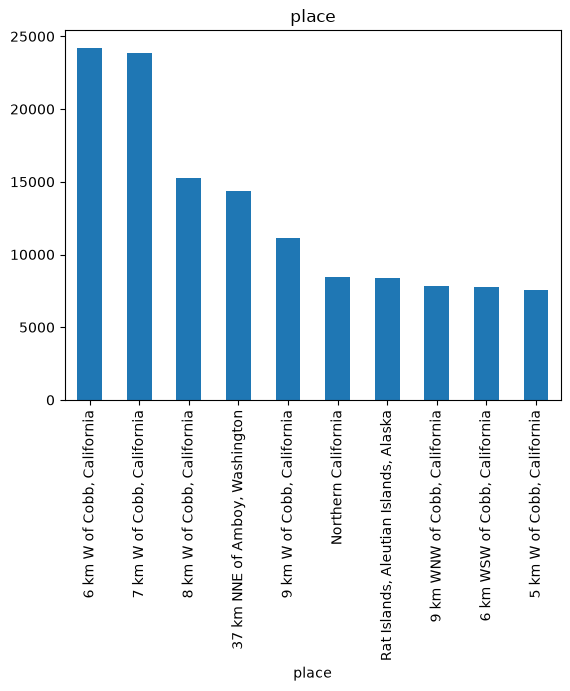

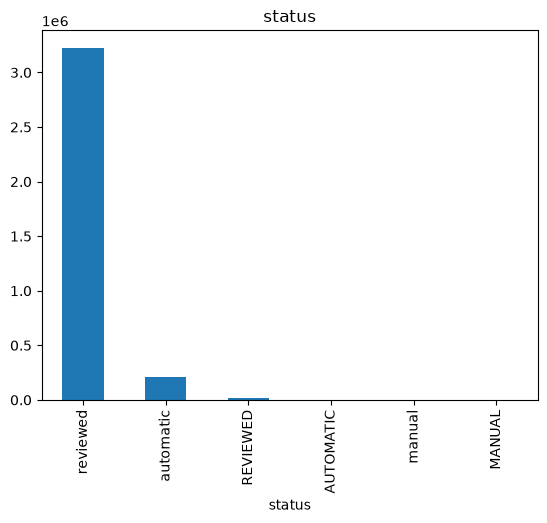

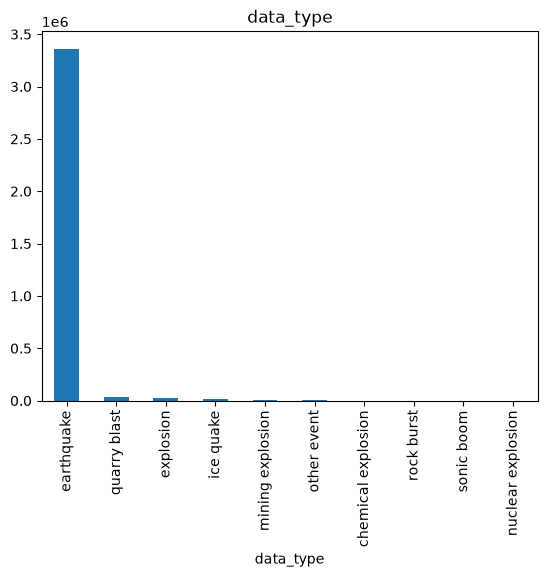

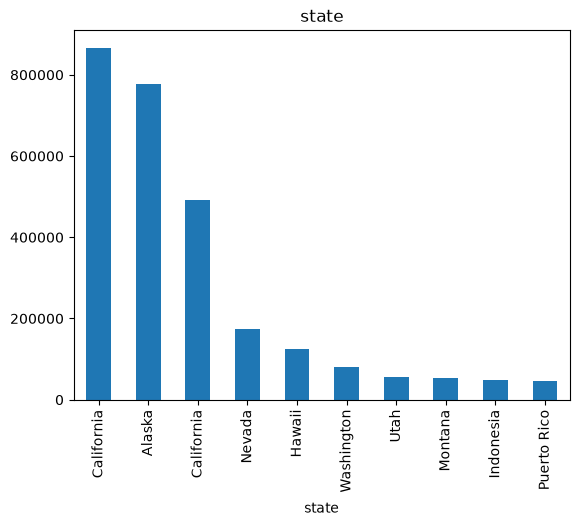

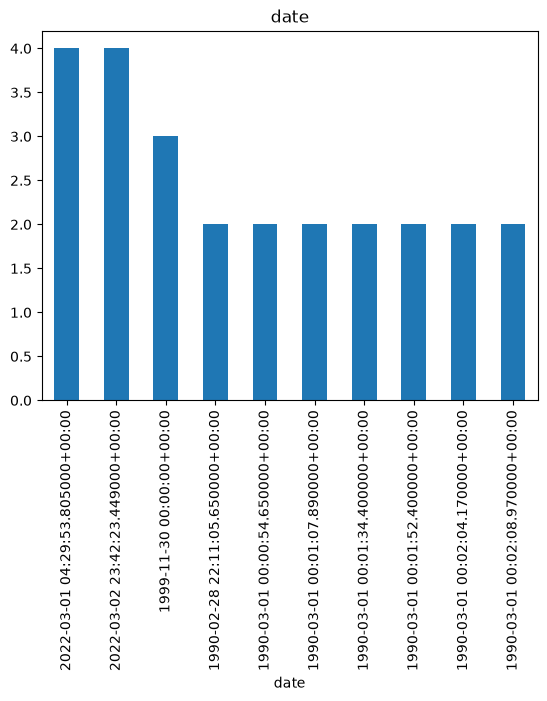

In [5]:
# Plot top 10 value counts for each categorical column
for column in df.select_dtypes(include=['object']).columns:
    df[column].value_counts()[:10].plot(kind='bar')  # top 10 categories
    plt.title(column)
    plt.show()

### Step 6 — Top N Strongest Earthquakes (Function)
Define a reusable function that sorts the DataFrame by magnitude and plots the top `n` earthquakes as a bar chart.

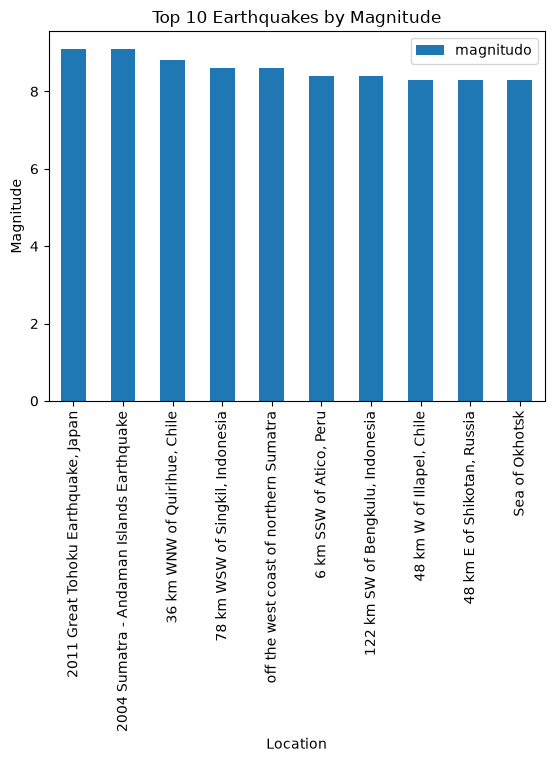

In [6]:
def plot_strongest_earthquakes(df, n=10):
    # sort the dataframe by the magnitude of the earthquakes
    df_sorted = df.sort_values(by="magnitudo", ascending=False)
    # take the top n earthquakes
    top_n = df_sorted.head(n)
    top_n.plot(kind='bar', x='place', y='magnitudo')
    plt.title('Top {} Earthquakes by Magnitude'.format(n))
    plt.xlabel('Location')
    plt.ylabel('Magnitude')
    plt.show()

plot_strongest_earthquakes(df)

The function sorts the DataFrame by magnitude in descending order, selects the top `n` rows, and renders them as a bar chart for quick comparison.

Check the raw format of the `date` column before parsing.

### Step 7 — Inspect the Date Column
Preview raw date values to confirm their format before parsing.

In [7]:
df['date'].head()

0    1990-01-01 00:22:33.990000+00:00
1    1990-01-01 00:24:51.210000+00:00
2    1990-01-01 00:34:43.450000+00:00
3    1990-01-01 00:58:32.130000+00:00
4    1990-01-01 01:03:44.490000+00:00
Name: date, dtype: str

Visualize earthquake locations and magnitudes using an animated scatter plot.

### Step 8 — Filter Data by Magnitude and State
Create subsets of the data for earthquakes with magnitude > 7 and for specific states (California, Alaska, Nevada) to enable focused analysis.

In [8]:
# Filter earthquakes by magnitude and location
filtered_magnitudo  = df[df['magnitudo'] > 7]           # magnitude > 7

filtered_California = df[df['state'] == 'California']   # earthquakes in California
filtered_Alaska     = df[df['state'] == 'Alaska']       # earthquakes in Alaska
filtered_Nevada     = df[df['state'] == 'Nevada']       # earthquakes in Nevada

### Step 9 — Magnitude Trend for Strong Earthquakes
Group earthquakes with magnitude > 7 by date, sum their magnitudes, and plot the result as an interactive line chart.

In [9]:
import plotly.express as px

# Group high-magnitude earthquakes by date and sum magnitudes
magnitudo_date = filtered_magnitudo.groupby('date')['magnitudo'].sum().reset_index()

# Line plot: cumulative magnitude over time for earthquakes > 7
fig = px.line(
    magnitudo_date,
    x='date', y='magnitudo',
    title='Total Magnitude of Earthquakes > 7 Over Time',
    labels={'date': 'Date', 'magnitudo': 'Total Magnitude'}
)
fig.show()

### Step 10 — Average Magnitude by Year
Extract the year from the date column and plot the average earthquake magnitude per year as a bar chart.

In [10]:
# Extract year from the date column
df['year'] = pd.to_datetime(df['date'], format='mixed').dt.year

# Calculate average magnitude per year
magnitudo_by_year = df.groupby('year')['magnitudo'].mean().reset_index()

# Bar plot: average magnitude by year
fig = px.bar(
    magnitudo_by_year,
    x='year', y='magnitudo',
    title='Average Earthquake Magnitude by Year',
    labels={'year': 'Year', 'magnitudo': 'Avg Magnitude'}
)
fig.show()

### Step 11 — Parse Dates and Count by Year
Convert the date column to a proper datetime type, extract the year, and count how many earthquakes occurred each year.

In [12]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format='mixed')

# Extract year
df['year'] = df['date'].dt.year

# Count earthquakes per year
year_counts = df['year'].value_counts().sort_index()
year_counts

### Step 12 — Strongest Earthquake per State
For each state, find the earthquake with the highest magnitude and significance, then visualize them on an interactive map.

In [14]:
def plot_strongest(df):
    gb_top = df.groupby(["state"])\
               .agg({"significance":"max", "magnitudo":"max"})\
               .reset_index()

    b = df[["year", "state","significance","longitude", "latitude","magnitudo"]]
    merge = pd.merge(gb_top, b, how = "left", on =["state","significance", "magnitudo"]).sort_values(by="year")


    fig = px.scatter_geo(merge, 
                         lat="latitude", lon="longitude", 
                         size="significance",
                         animation_frame="year",
                         projection="natural earth",
                         title = "Strongest eartquake by year")
    fig.show()
    
plot_strongest(df)

### Step 13 — Earthquake Frequency Histogram by Year
Plot a histogram (with KDE curve) showing how the number of recorded earthquakes is distributed across years.

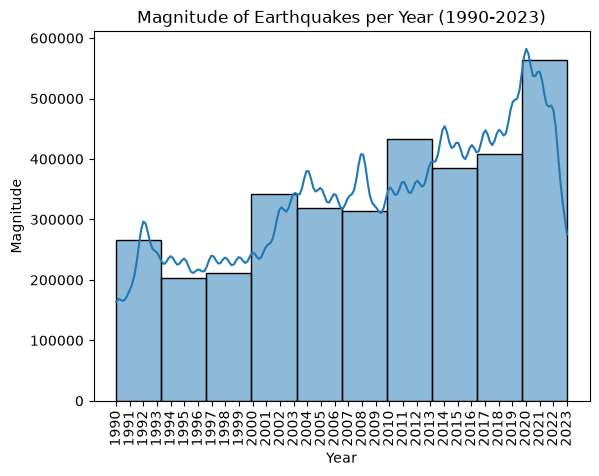

In [19]:
# Extract year as numeric
df['year'] = pd.to_numeric(df.date.dt.year)

# Histogram: earthquake frequency distribution per year
plot_data = df[['year', 'magnitudo']]
sns.histplot(data=plot_data, bins=10, kde=True, x='year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Earthquake Frequency by Year')
plt.show()

### Step 15 — Generate Predictions
Use the trained model to predict magnitudes for the test set.

### Step 14 — Machine Learning: Predict Magnitude
Train a Linear Regression model using depth, latitude, and longitude as features to predict earthquake magnitude. Evaluate performance using Mean Squared Error (MSE).

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Select numeric features for predicting earthquake magnitude
numerical_columns = ['magnitudo', 'depth', 'latitude', 'longitude']
data = df[numerical_columns].dropna()

X = data[['depth', 'latitude', 'longitude']]
y = data['magnitudo']

# Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.4f}')

Mean Squared Error: 0.9057304781040546


In [21]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

### Step 16 — Actual vs. Predicted Comparison
Sample every 1000th prediction and compare actual vs. predicted magnitudes to visually assess model accuracy.

In [22]:
# Sample every 1000th prediction to keep the plot manageable
fig_data = [
    (i, actual, predicted)
    for i, (actual, predicted) in enumerate(zip(y_test, y_pred), 1)
    if i % 1000 == 0
]

# Build a comparison DataFrame (actual vs predicted magnitude)
df_fig = pd.DataFrame(fig_data, columns=['Iteration', 'Actual', 'Predicted'])

### Step 17 — Top 20 Strongest Earthquakes
Rank all earthquakes by magnitude and display the top 20 as a horizontal bar chart with value labels.

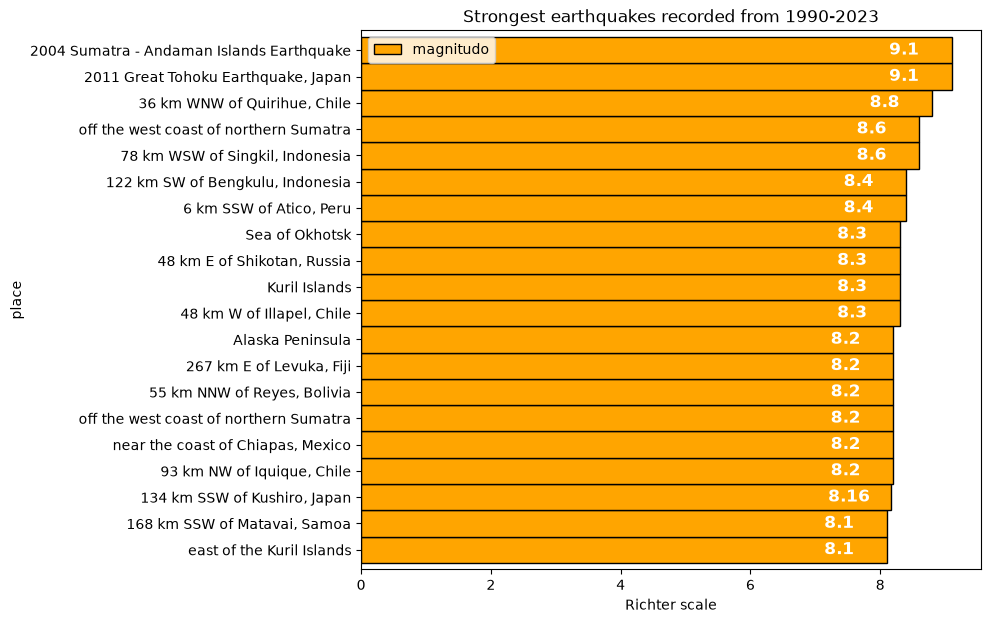

In [23]:
# Horizontal bar chart: top 20 strongest earthquakes by magnitude
top_mag = df.sort_values(by='magnitudo', ascending=False).head(20)

plot = top_mag.sort_values(by='magnitudo').plot(
    x='place', y='magnitudo', kind='barh',
    width=1, edgecolor='black', figsize=(8, 7), color='orange'
)
for bars in plot.containers:
    plot.bar_label(bars, padding=-45, fontsize=12)

### Step 18 — Extract Time Features
Derive month, month name, and day-of-month columns from the date field for temporal pattern analysis.

In [24]:
# Extract time components from the date column
df['date']         = pd.to_datetime(df['date'])
df['month']        = df['date'].dt.month
df['month_name']   = df['date'].dt.month_name()
df['day_of_month'] = df['date'].dt.day

# Average magnitude per year
magnitude_by_year = df.groupby('year')['magnitudo'].mean()

**Note:** Earthquake occurrence cannot be predicted precisely. However, this model estimates *magnitude* from depth and coordinates as a useful baseline.

### Step 19 — Predict Future Magnitudes (Hypothetical)
Generate random geographic inputs within the observed data range and use the trained model to predict their magnitudes on a scatter map.

In [25]:
import numpy as np
import plotly.express as px

# Generate hypothetical data within the observed range
new_data = pd.DataFrame({
    'depth':     np.random.uniform(df['depth'].min(),     df['depth'].max(),     100),
    'latitude':  np.random.uniform(df['latitude'].min(),  df['latitude'].max(),  100),
    'longitude': np.random.uniform(df['longitude'].min(), df['longitude'].max(), 100)
})

# Predict magnitudes for hypothetical locations
new_data['predicted_magnitude'] = model.predict(new_data)

# Scatter plot: predicted magnitudes on a world map projection
fig = px.scatter(
    new_data, x='longitude', y='latitude',
    color='predicted_magnitude',
    title='Predicted Earthquake Magnitudes (Hypothetical Locations)',
    color_continuous_scale='Reds'
)
fig.show()

Depth, latitude, and longitude values are randomly sampled within the observed dataset range. The trained model predicts magnitudes for these synthetic points to illustrate geographic patterns.

### Step 20 — Final Report
Print a structured summary covering data source, methodology, insights, challenges, and conclusions.

In [17]:
# Define the report content
report_content = """
# Earthquake Analysis Report (1990–2023)

## Data Source
Dataset: `Eartquakes-1990-2023.csv` — ~3.4 million earthquake records with features including magnitude, depth, location, state, and date.

## Methodology
- Examined data structure, summary statistics, and unique categorical values.
- Visualized category distributions and plotted the strongest earthquakes by magnitude.
- Extracted time features (year, month, day) and filtered data by state and magnitude for targeted analysis.
- Dropped non-numeric columns, split data (80/20), and trained a Linear Regression model to predict magnitude from depth, latitude, and longitude.

## Analysis Techniques
Bar plots, histograms, scatter plots, and correlation heatmaps were used for exploration. Scikit-learn's Linear Regression (OLS) was used for prediction.

## Key Insights
- Earthquake magnitudes varied significantly across years and states, with notable spikes in specific regions.
- No strong temporal pattern was found by month; slight variation appeared across days of the month.
- The Linear Regression model showed limited accuracy, reflecting the inherently unpredictable nature of earthquakes.

## Challenges
- Mixing categorical data (e.g., state) with numeric features required careful preprocessing.
- Predicting earthquake magnitude is inherently difficult due to the irregular nature of seismic activity.

## Conclusion
The analysis revealed meaningful patterns in earthquake frequency and magnitude across states and time. While prediction accuracy was limited, the project demonstrated the value of EDA and machine learning in understanding complex geophysical data.
"""

print(report_content)



# Earthquake Analysis Report (1990–2023)

## Data Source
Dataset: `Eartquakes-1990-2023.csv` — ~3.4 million earthquake records with features including magnitude, depth, location, state, and date.

## Methodology
- Examined data structure, summary statistics, and unique categorical values.
- Visualized category distributions and plotted the strongest earthquakes by magnitude.
- Extracted time features (year, month, day) and filtered data by state and magnitude for targeted analysis.
- Dropped non-numeric columns, split data (80/20), and trained a Linear Regression model to predict magnitude from depth, latitude, and longitude.

## Analysis Techniques
Bar plots, histograms, scatter plots, and correlation heatmaps were used for exploration. Scikit-learn's Linear Regression (OLS) was used for prediction.

## Key Insights
- Earthquake magnitudes varied significantly across years and states, with notable spikes in specific regions.
- No strong temporal pattern was found by month; slight var

> 